# MECE

In [1]:
import pandas as pd
from IPython.display import display

# Define the data as a list of lists (excluding 'Individual Responsible' column)
data = [
    ["Causal transformer model using position encodings", "Config of the model trained", "Train Time = 5851.17 seconds"],
    ["Training Data Check", "Confusion Matrix Built?", "Yes"],
    ["", "F1 Score for Positive = ?", "0.7949"],
    ["", "F1 Score for Negative = ?", "0.0000"],
    ["", "AUC plotted?", "Yes"],
    ["", "AUC = ", "AUC for Negative on Training Data: 0.4721, AUC for Neutral on Training Data: 0.4872, AUC for Positive on Training Data: 0.5126"],
    ["", "Accuracy computed?", "0.6596"],
    ["Cross Validation", "", ""],
    ["Interpretability", "local(LIME)", "Words highly associated with the negative setiment"],
    ["Testing Data Check", "Confusion Matrix Built?", "Yes"],
    ["", "F1 Score for Positive = ?", ""],
    ["", "F1 Score for Negative = ?", ""],
    ["", "AUC plotted?", ""],
    ["", "AUC = ", "AUC for Class 0 on Test Data: , AUC for Class 1 on Test Data: , AUC for Class 2 on Test Data: "],
    ["", "Accuracy computed?", ""],    
    ["Data Preprocessing and Feature Engg", "Regex Used?", "yes"],
    ["", "Emoji Handling Done?", "yes"],
    ["", "Slang Handling Done?", "yes"],
    ["", "Abbreviations Handled?", "yes"],
    ["", "Negation Handled?", "yes"],
    ["", "Class Separability Checked?", "yes"],
    ["", "Train and Test Handled Correctly?", "yes"],
]

# Create a DataFrame
Task = pd.DataFrame(data, columns=["Task", "Status", "Results"])

# Display the table in Jupyter Notebook
display(Task)

,Task,Status,Results
0,Causal transformer model using position encodings,Config of the model trained,Train Time = 5851.17 seconds
1,Training Data Check,Confusion Matrix Built?,Yes
2,,F1 Score for Positive = ?,0.7949
3,,F1 Score for Negative = ?,0.0000
4,,AUC plotted?,Yes
5,,AUC =,"AUC for Negative on Training Data: 0.4721, AUC..."
6,,Accuracy computed?,0.6596
7,Cross Validation,,
8,Interpretability,local(LIME),Words highly associated with the negative seti...
9,Testing Data Check,Confusion Matrix Built?,Yes


# Import Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import time
import imblearn
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

#  Load and Explore the Dataset

In [2]:
# Define the dataset path
data_path = r"C:\Users\ASUS\OneDrive\Documents\Desktop\NLP\Sentiment_Data\Sentiment_Data.csv"

# Load the dataset with encoding
df = pd.read_csv(data_path, encoding="ISO-8859-1")  # or try "latin-1"

# Display the first few rows
print(df.head())

# Check dataset information
print(df.info())


                                               Tweet Sentiment
0  @_angelica_toy Happy Anniversary!!!....The Day...  Mild_Pos
1  @McfarlaneGlenda Happy Anniversary!!!....The D...  Mild_Pos
2  @thevivafrei @JustinTrudeau Happy Anniversary!...  Mild_Pos
3  @NChartierET Happy Anniversary!!!....The Day t...  Mild_Pos
4  @tabithapeters05 Happy Anniversary!!!....The D...  Mild_Pos
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451332 entries, 0 to 451331
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Tweet      451331 non-null  object
 1   Sentiment  451332 non-null  object
dtypes: object(2)
memory usage: 6.9+ MB
None


# Map Sentiments to Three Categories

In [3]:
# Check unique sentiment labels
print(df["Sentiment"].value_counts())


Strong_Pos    233700
Neutral        77016
Mild_Pos       64004
Strong_Neg     42556
Mild_Neg       34056
Name: Sentiment, dtype: int64


In [4]:
# Function to map sentiment labels into three categories
def map_sentiment(label):
    if label in ["Strong_Pos", "Mild_Pos"]:
        return "Positive"
    elif label in ["Strong_Neg", "Mild_Neg"]:
        return "Negative"
    else:
        return "Neutral"

# Apply the mapping function
df["Sentiment"] = df["Sentiment"].apply(map_sentiment)

# Check new distribution
print(df["Sentiment"].value_counts())





Positive    297704
Neutral      77016
Negative     76612
Name: Sentiment, dtype: int64


# Take a Sample

In [5]:
from sklearn.model_selection import train_test_split

# Take a sample (to get at least 5000 test samples)
sample_size = 25000  # Adjust as needed
df_sample = df.groupby('Sentiment', group_keys=False).apply(lambda x: x.sample(frac=sample_size / len(df), random_state=42))

# Check sample size and distribution
print(df_sample.shape)
print(df_sample['Sentiment'].value_counts(normalize=True))


(25000, 2)
Positive    0.65960
Neutral     0.17064
Negative    0.16976
Name: Sentiment, dtype: float64


# Stratified Sampling

In [6]:
# Define input and target columns
X = df_sample['Tweet']
y = df_sample['Sentiment']

# Stratified split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Check distribution and size after split
print("Training Data Size:", X_train.shape[0])
print("Testing Data Size:", X_test.shape[0])
print("\nTraining Data Distribution:\n", y_train.value_counts(normalize=True))
print("\nTesting Data Distribution:\n", y_test.value_counts(normalize=True))

Training Data Size: 20000
Testing Data Size: 5000

Training Data Distribution:
 Positive    0.65960
Neutral     0.17065
Negative    0.16975
Name: Sentiment, dtype: float64

Testing Data Distribution:
 Positive    0.6596
Neutral     0.1706
Negative    0.1698
Name: Sentiment, dtype: float64


# Tokenization + Padding

In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenization settings
MAX_NUM_WORDS = 20000
MAX_SEQUENCE_LENGTH = 100

# Initialize Tokenizer
tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences to equal length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

# Check shape
print("Padded Training Data Shape:", X_train_pad.shape)
print("Padded Testing Data Shape:", X_test_pad.shape)


Padded Training Data Shape: (20000, 100)
Padded Testing Data Shape: (5000, 100)



# Apply SMOTE

In [8]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE on padded sequences
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_pad, y_train)

# Check resampled distribution
print("Resampled Training Data Distribution:\n", y_train_resampled.value_counts(normalize=True))


Resampled Training Data Distribution:
 Positive    0.333333
Negative    0.333333
Neutral     0.333333
Name: Sentiment, dtype: float64


# Apply Label Encoding¶

In [9]:
from sklearn.preprocessing import LabelEncoder

# Initialize the label encoder
label_encoder = LabelEncoder()

# Fit and transform the labels
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# If you need to decode the labels back to original
# y_train_decoded = label_encoder.inverse_transform(y_train_encoded)

# Check the encoded labels
print("Encoded Training Labels:\n", y_train_encoded[:10])
print("Encoded Testing Labels:\n", y_test_encoded[:10])



Encoded Training Labels:
 [2 2 2 0 2 0 2 2 2 2]
Encoded Testing Labels:
 [2 2 2 2 2 0 1 2 1 2]


In [10]:
pip install emoji

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Data Preprocessing


In [11]:
import re
import emoji
from collections import defaultdict

# Initialize counters
regex_count = 0
emoji_count = 0
slang_count = 0
abbreviation_count = 0
negation_count = 0

# Define slang and abbreviations dictionaries
slang_dict = {
    "lol": "laugh out loud",
    "omg": "oh my god",
    "idk": "i don't know",
    "btw": "by the way",
    "brb": "be right back",
    "imo": "in my opinion",
    "smh": "shaking my head"
}

abbreviation_dict = {
    "u": "you",
    "r": "are",
    "ur": "your",
    "pls": "please",
    "w/": "with",
    "b4": "before",
    "l8r": "later"
}

# Function to clean text
def preprocess_text(text):
    global regex_count, emoji_count, slang_count, abbreviation_count, negation_count
    
    # 1. **Convert to lowercase**
    text = text.lower()
    
    # 2. **Remove URLs**
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    regex_count += 1
    
    # 3. **Remove mentions (@username)**
    text = re.sub(r"@\w+", "", text)
    regex_count += 1
    
    # 4. **Remove hashtags (keep the content)**
    text = re.sub(r"#(\w+)", r"\1", text)
    regex_count += 1
    
    # 5. **Remove special characters and punctuations**
    text = re.sub(r"[^\w\s]", "", text)
    regex_count += 1
    
    # 6. **Emoji Handling**
    text = emoji.demojize(text, delimiters=(" ", " "))
    emoji_count += sum(1 for _ in re.finditer(r":\w+:", text))
    
    # 7. **Slang Handling**
    for word in slang_dict:
        if word in text:
            text = text.replace(word, slang_dict[word])
            slang_count += 1
    
    # 8. **Abbreviation Handling**
    for abbr in abbreviation_dict:
        if abbr in text:
            text = text.replace(abbr, abbreviation_dict[abbr])
            abbreviation_count += 1
    
    # 9. **Negation Handling**
    negation_patterns = {
        "can't": "can not",
        "won't": "will not",
        "n't": " not",
        "i'm": "i am",
        "it's": "it is",
        "he's": "he is",
        "she's": "she is",
        "they're": "they are",
        "we're": "we are",
        "you're": "you are"
    }
    
    for neg in negation_patterns:
        if neg in text:
            text = text.replace(neg, negation_patterns[neg])
            negation_count += 1
    
    return text

# Apply preprocessing to the data
X_train_clean = X_train.apply(preprocess_text)
X_test_clean = X_test.apply(preprocess_text)

# Show preprocessed examples
print("\nSample Preprocessed Text (Training Data):\n", X_train_clean.head(5))

# Summary of preprocessing
print("\n--- Preprocessing Summary ---")
print(f"Total Regex Patterns Used: {regex_count}")
print(f"Total Emojis Handled: {emoji_count}")
print(f"Total Slang Terms Handled: {slang_count}")
print(f"Total Abbreviations Handled: {abbreviation_count}")
print(f"Total Negation Patterns Handled: {negation_count}")

# Tokenization after cleaning
tokenizer.fit_on_texts(X_train_clean)
X_train_seq = tokenizer.texts_to_sequences(X_train_clean)
X_test_seq = tokenizer.texts_to_sequences(X_test_clean)

# Pad sequences to equal length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

# Shape check
print("\nPadded Training Data Shape:", X_train_pad.shape)
print("Padded Testing Data Shape:", X_test_pad.shape)



Sample Preprocessed Text (Training Data):
 149827     i think fareeedom convoy eveareyone bareings ...
116298     itâs engagement like this that coyould have p...
158659     thanks fareeedom convoy the ndp and libeareal...
270417     hypocareisy has no limits\n\nfareeedomconvoy ...
306087    i wondeare who is youltimately playing these â...
Name: Tweet, dtype: object

--- Preprocessing Summary ---
Total Regex Patterns Used: 100000
Total Emojis Handled: 0
Total Slang Terms Handled: 353
Total Abbreviations Handled: 46396
Total Negation Patterns Handled: 7

Padded Training Data Shape: (20000, 100)
Padded Testing Data Shape: (5000, 100)


# Model

In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# Parameters for the model
VOCAB_SIZE = len(tokenizer.word_index) + 1  # Vocabulary size (including padding)
EMBEDDING_DIM = 128  # Dimension for word embeddings (you can change this)
NUM_HEADS = 8  # Number of attention heads
NUM_LAYERS = 4  # Number of transformer layers
DFF = 512  # Feed-forward network dimension
HIDDEN_SIZE = 256  # Hidden state size (memory size)
DROPOUT_RATE = 0.1  # Dropout rate
MAX_SEQ_LENGTH = MAX_SEQUENCE_LENGTH  # Sequence length (input padding)

# Causal Transformer Block
def transformer_block(inputs, hidden_size, num_heads, dff, dropout_rate):
    # Multi-head Attention Layer (Causal Masking)
    attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=hidden_size, dropout=dropout_rate)(inputs, inputs)
    attention = layers.Dropout(dropout_rate)(attention)
    attention = layers.LayerNormalization(epsilon=1e-6)(attention + inputs)

    # Feed-Forward Network
    ffn = layers.Dense(dff, activation='relu')(attention)
    ffn = layers.Dropout(dropout_rate)(ffn)
    ffn = layers.Dense(hidden_size)(ffn)
    ffn = layers.Dropout(dropout_rate)(ffn)
    
    # Add & Normalize
    ffn_out = layers.LayerNormalization(epsilon=1e-6)(ffn + attention)

    return ffn_out

# Positional Encoding Layer (Now matches the hidden size dimension)
def get_position_encoding(seq_len, d_model):
    position = np.arange(seq_len)[:, np.newaxis]
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
    pos_encoding = np.zeros((seq_len, d_model))
    pos_encoding[:, 0::2] = np.sin(position * div_term)
    pos_encoding[:, 1::2] = np.cos(position * div_term)
    
    return pos_encoding

# Build the Model
inputs = layers.Input(shape=(MAX_SEQ_LENGTH,))
embedding_layer = layers.Embedding(input_dim=VOCAB_SIZE, output_dim=HIDDEN_SIZE, input_length=MAX_SEQ_LENGTH)(inputs)

# Add Positional Encoding (Now HIDDEN_SIZE)
position_encoding = get_position_encoding(MAX_SEQ_LENGTH, HIDDEN_SIZE)
position_encoding_layer = layers.Lambda(lambda x: x + position_encoding)(embedding_layer)

# Transformer Layers
x = position_encoding_layer
for _ in range(NUM_LAYERS):
    x = transformer_block(x, HIDDEN_SIZE, NUM_HEADS, DFF, DROPOUT_RATE)

# Output Layer
x = layers.GlobalAveragePooling1D()(x)
output = layers.Dense(3, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=output)

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()

# Model Train Time Estimation
start_time = time.time()

# Train the model
history = model.fit(X_train_pad, y_train_encoded, epochs=5, batch_size=32, validation_data=(X_test_pad, y_test_encoded))

train_time = time.time() - start_time
print(f"Model Training Time: {train_time:.2f} seconds")


C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 100)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 100, 256)          │      18,142,464 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda (Lambda)               │ (None, 100, 256)          │               0 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention          │ (None, 100, 256)          │       2,103,552 │ lambda[0][0], lambda[0][0] │
│ (MultiHeadAttention)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 100, 256)          │               0 │ multi_head_attention[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 100, 256)          │               0 │ dropout_1[0][0],           │
│                               │                           │                 │ lambda[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 100, 256)          │             512 │ add[0][0]                  │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 100, 512)          │         131,584 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 100, 512)          │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 100, 256)          │         131,328 │ dropout_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_3 (Dropout)           │ (None, 100, 256)          │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_1 (Add)                   │ (None, 100, 256)          │               0 │ dropout_3[0][0],           │
│                               │                           │                 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_1         │ (None, 100, 256)          │             512 │ add_1[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention_1        │ (None, 100, 256)          │       2,103,552 │ layer_normalization_1[0][… │
│ (MultiHeadAttention)          │                           │                 │ layer_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 27,613,187 (105.34 MB)

 Trainable params: 27,613,187 (105.34 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1710s 3s/step - accuracy: 0.6373 - loss: 1.0765 - val_accuracy: 0.6596 - val_loss: 0.9109
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1585s 3s/step - accuracy: 0.6588 - loss: 0.8900 - val_accuracy: 0.6596 - val_loss: 0.9018
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 840s 1s/step - accuracy: 0.6641 - loss: 0.8826 - val_accuracy: 0.6596 - val_loss: 0.8812
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 869s 1s/step - accuracy: 0.6559 - loss: 0.8892 - val_accuracy: 0.6596 - val_loss: 0.8781
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 847s 1s/step - accuracy: 0.6558 - loss: 0.8865 - val_accuracy: 0.6596 - val_loss: 0.8775
Model Training Time: 5851.17 seconds


In [13]:
# --- Model Training Summary ---
# Model Configurations
print("\n--- Model Training Summary ---")
print(f"Model Configurations:")
print(f" - Vocabulary Size: {VOCAB_SIZE}")
print(f" - Embedding Dimension: {EMBEDDING_DIM}")
print(f" - Number of Heads: {NUM_HEADS}")
print(f" - Feedforward Dimension: {DFF}")
print(f" - Max Sequence Length: {MAX_SEQ_LENGTH}")
print(f" - Number of Classes: {3}")  # Assuming 3 classes: Positive, Negative, Neutral

# Hidden Memory Size Calculation
hidden_memory_size = HIDDEN_SIZE * MAX_SEQ_LENGTH  # Hidden memory size (each token's hidden state dimension)
print(f"Hidden Memory Size: {hidden_memory_size} (Hidden Size * Sequence Length)")

# Train Time (from previous code)
train_time = time.time() - start_time
print(f"Train Time: {train_time:.2f} seconds")

# Test Accuracy
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test_encoded)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")



--- Model Training Summary ---
Model Configurations:
 - Vocabulary Size: 70869
 - Embedding Dimension: 128
 - Number of Heads: 8
 - Feedforward Dimension: 512
 - Max Sequence Length: 100
 - Number of Classes: 3
Hidden Memory Size: 25600 (Hidden Size * Sequence Length)
Train Time: 5851.30 seconds
157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 358ms/step - accuracy: 0.6523 - loss: 0.8869
Test Accuracy: 65.96%


157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 361ms/step


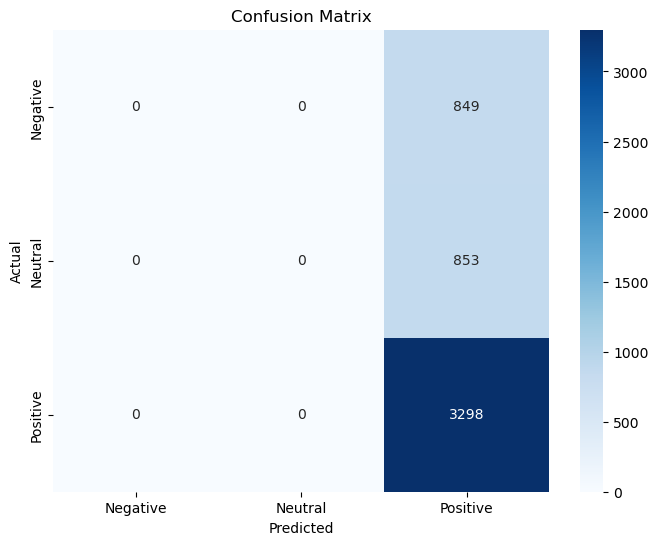


✅ F1 Score for Positive = 0.7949
✅ F1 Score for Negative = 0.0000
✅ Accuracy = 0.6596


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


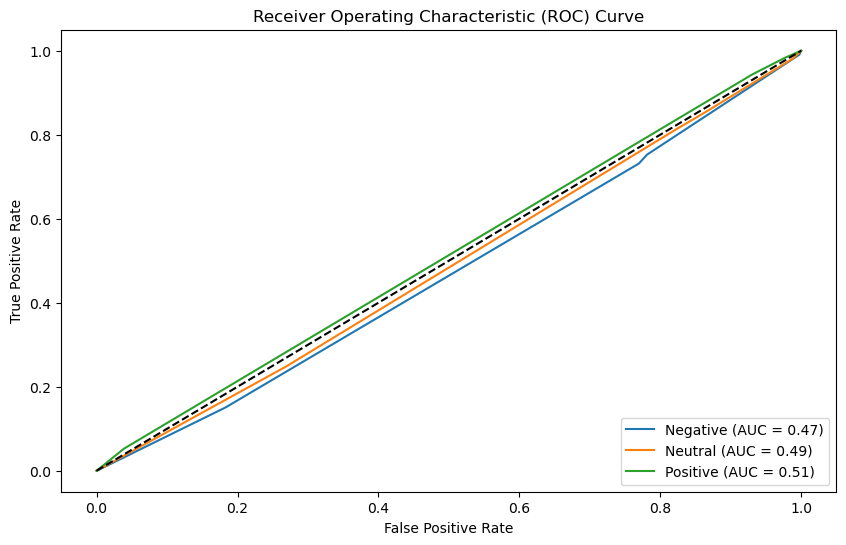

✅ AUC for Negative = 0.4721
✅ AUC for Neutral = 0.4872
✅ AUC for Positive = 0.5126


In [14]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict on the test data
y_test_pred = model.predict(X_test_pad)
y_test_pred_classes = np.argmax(y_test_pred, axis=1)

# Compute Confusion Matrix
conf_matrix = confusion_matrix(y_test_encoded, y_test_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Classification Report
report = classification_report(y_test_encoded, y_test_pred_classes, target_names=label_encoder.classes_, output_dict=True)

f1_positive = report['Positive']['f1-score']
f1_negative = report['Negative']['f1-score']
accuracy = report['accuracy']

print(f"\n✅ F1 Score for Positive = {f1_positive:.4f}")
print(f"✅ F1 Score for Negative = {f1_negative:.4f}")
print(f"✅ Accuracy = {accuracy:.4f}")

# 🔍 Compute AUC
y_test_binarized = tf.keras.utils.to_categorical(y_test_encoded, num_classes=len(label_encoder.classes_))

plt.figure(figsize=(10, 6))
for i, label in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_test_pred[:, i])
    auc_score = roc_auc_score(y_test_binarized[:, i], y_test_pred[:, i])
    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_score:.2f})")

# Reference line
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

# Print AUC values
for i, label in enumerate(label_encoder.classes_):
    auc_score = roc_auc_score(y_test_binarized[:, i], y_test_pred[:, i])
    print(f"✅ AUC for {label} = {auc_score:.4f}")


# Hyperparameter Tuning

In [16]:
pip install keras-tuner



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/129.1 kB ? eta -:--:--
   --- ------------------------------------ 10.2/129.1 kB ? eta -:--:--
   --------- ----------------------------- 30.7/129.1 kB 660.6 kB/s eta 0:00:01
   --------------------------- ----------- 92.2/129.1 kB 871.5 kB/s eta 0:00:01
   -------------------------------------- 129.1/129.1 kB 951.3 kB/s eta 0:00:00


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import keras_tuner as kt
import time

# Parameters for the model
VOCAB_SIZE = len(tokenizer.word_index) + 1
MAX_SEQ_LENGTH = MAX_SEQUENCE_LENGTH

# Positional Encoding Layer
def get_position_encoding(seq_len, d_model):
    position = np.arange(seq_len)[:, np.newaxis]
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
    pos_encoding = np.zeros((seq_len, d_model))
    pos_encoding[:, 0::2] = np.sin(position * div_term)
    pos_encoding[:, 1::2] = np.cos(position * div_term)
    return pos_encoding

# Transformer Block
def transformer_block(inputs, hidden_size, num_heads, dff, dropout_rate):
    attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=hidden_size)(inputs, inputs)
    attention = layers.Dropout(dropout_rate)(attention)
    attention = layers.LayerNormalization(epsilon=1e-6)(inputs + attention)

    # Feed-Forward Network
    ffn = layers.Dense(dff, activation='relu')(attention)
    ffn = layers.Dropout(dropout_rate)(ffn)
    ffn = layers.Dense(hidden_size)(ffn)
    ffn = layers.Dropout(dropout_rate)(ffn)

    # Add & Normalize
    ffn_out = layers.LayerNormalization(epsilon=1e-6)(attention + ffn)

    return ffn_out

# Hyperparameter Tuning Function
def build_model(hp):
    EMBEDDING_DIM = hp.Int('embedding_dim', min_value=64, max_value=256, step=32)
    NUM_HEADS = hp.Choice('num_heads', values=[4, 8, 12])
    NUM_LAYERS = hp.Int('num_layers', min_value=2, max_value=6, step=1)
    DFF = hp.Int('dff', min_value=256, max_value=1024, step=128)
    HIDDEN_SIZE = hp.Int('hidden_size', min_value=128, max_value=512, step=64)
    DROPOUT_RATE = hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)

    inputs = layers.Input(shape=(MAX_SEQ_LENGTH,))
    embedding_layer = layers.Embedding(input_dim=VOCAB_SIZE, output_dim=HIDDEN_SIZE, input_length=MAX_SEQ_LENGTH)(inputs)

    # Positional Encoding Fix
    position_encoding = get_position_encoding(MAX_SEQ_LENGTH, HIDDEN_SIZE)
    position_encoding_layer = layers.Lambda(lambda x: x + position_encoding)(embedding_layer)

    x = position_encoding_layer
    for _ in range(NUM_LAYERS):
        x = transformer_block(x, HIDDEN_SIZE, NUM_HEADS, DFF, DROPOUT_RATE)

    x = layers.GlobalAveragePooling1D()(x)
    output = layers.Dense(3, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=output)
    
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    return model

# Create Tuner
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='hyper_tuning',
    project_name='transformer_tuning'
)

# Train Tuner
start_time = time.time()

tuner.search(X_train_pad, y_train_encoded,
             epochs=10,
             batch_size=32,
             validation_data=(X_test_pad, y_test_encoded))

train_time = time.time() - start_time
print(f"Tuning Time: {train_time:.2f} seconds")

# Get the Best Hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Best Hyperparameters:
- Embedding Dimension: {best_hps.get('embedding_dim')}
- Number of Heads: {best_hps.get('num_heads')}
- Number of Layers: {best_hps.get('num_layers')}
- Feed Forward Network Size: {best_hps.get('dff')}
- Hidden Size: {best_hps.get('hidden_size')}
- Dropout Rate: {best_hps.get('dropout_rate')}
""")

# Build Final Model with Best Hyperparameters
model = tuner.hypermodel.build(best_hps)

# Train Final Model
history = model.fit(X_train_pad, y_train_encoded,
                    epochs=10,
                    batch_size=32,
                    validation_data=(X_test_pad, y_test_encoded))

# Model Summary
model.summary()


Trial 7 Complete [00h 40m 10s]

Best val_accuracy So Far: 0.659600019454956
Total elapsed time: 04h 51m 23s

Search: Running Trial #8

Value             |Best Value So Far |Hyperparameter
256               |128               |embedding_dim
12                |4                 |num_heads
4                 |2                 |num_layers
768               |1024              |dff
512               |320               |hidden_size
0.2               |0.2               |dropout_rate
2                 |2                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
2                 |2                 |tuner/bracket
0                 |0                 |tuner/round

Epoch 1/2
107/625 ━━━━━━━━━━━━━━━━━━━━ 5:57:40 41s/step - accuracy: 0.5621 - loss: 2.3502

# Cross Validation

In [ ]:
from sklearn.model_selection import KFold
import numpy as np

# Number of folds
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Store results
cv_scores = []
fold_no = 1

# Save the initial weights to reset the model each time
initial_weights = model.get_weights()

for train_idx, val_idx in kf.split(X_train_pad):
    print(f"\nTraining on Fold {fold_no}...")

    # Split data into training and validation sets
    X_train_fold, X_val_fold = X_train_pad[train_idx], X_train_pad[val_idx]
    y_train_fold, y_val_fold = y_train_encoded[train_idx], y_train_encoded[val_idx]

    # Reset model to initial state (avoid recreating it)
    model.set_weights(initial_weights)

    # Train the model
    history = model.fit(
        X_train_fold, y_train_fold,
        epochs=5,
        batch_size=32,
        validation_data=(X_val_fold, y_val_fold),
        verbose=1
    )

    # Evaluate the model on validation data
    score = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"Fold {fold_no} - Loss: {score[0]:.4f}, Accuracy: {score[1]:.4f}")

    # Store the accuracy score
    cv_scores.append(score[1])
    fold_no += 1

# Print overall cross-validation accuracy
print(f"\nAverage Accuracy across {k} folds: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation of Accuracy: {np.std(cv_scores):.4f}")


In [ ]:
from sklearn.model_selection import KFold
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Reduce complexity if needed
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DFF = 128
DROPOUT_RATE = 0.1
NUM_HEADS = 4

# Early stopping callback
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', patience=2, restore_best_weights=True
)

# Use TensorFlow Dataset for faster handling
BATCH_SIZE = 32
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_pad, y_train_encoded))
train_dataset = train_dataset.shuffle(len(X_train_pad)).batch(BATCH_SIZE)

# Create model function
def create_model():
    inputs = layers.Input(shape=(MAX_SEQ_LENGTH,))
    embedding_layer = layers.Embedding(input_dim=VOCAB_SIZE, output_dim=HIDDEN_SIZE, input_length=MAX_SEQ_LENGTH)(inputs)

    # Positional Encoding
    position_encoding = get_position_encoding(MAX_SEQ_LENGTH, HIDDEN_SIZE)
    position_encoding_layer = layers.Lambda(lambda x: x + position_encoding)(embedding_layer)

    # Transformer Layers
    x = position_encoding_layer
    for _ in range(NUM_LAYERS):
        x = transformer_block(x, HIDDEN_SIZE, NUM_HEADS, DFF, DROPOUT_RATE)

    x = layers.GlobalAveragePooling1D()(x)
    output = layers.Dense(3, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Reduce number of splits
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

# Collect cross-validation results
cv_results = []

# Run cross-validation
for train_idx, val_idx in kfold.split(X_train_pad):
    X_train_cv, X_val_cv = X_train_pad[train_idx], X_train_pad[val_idx]
    y_train_cv, y_val_cv = y_train_encoded[train_idx], y_train_encoded[val_idx]
    
    # Create model
    model = create_model()
    
    # Train model with early stopping
    model.fit(
        X_train_cv, y_train_cv,
        validation_data=(X_val_cv, y_val_cv),
        epochs=3,  # Reduced epochs
        batch_size=BATCH_SIZE,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Evaluate model
    val_loss, val_accuracy = model.evaluate(X_val_cv, y_val_cv, verbose=0)
    cv_results.append(val_accuracy)

# Summary of cross-validation
print(f"Cross-Validation Accuracy Scores: {cv_results}")
print(f"Mean Cross-Validation Accuracy: {np.mean(cv_results):.4f}")
print(f"Standard Deviation of Cross-Validation Accuracy: {np.std(cv_results):.4f}")



# Testing Data Check

# Confusion Matrix and Classification Report

In [ ]:
# Predict on the test data
y_test_pred = model.predict(X_test_pad)
y_test_pred_classes = np.argmax(y_test_pred, axis=1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_encoded, y_test_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Classification Report
report = classification_report(y_test_encoded, y_test_pred_classes, target_names=label_encoder.classes_, output_dict=True)

# Print out F1-Score for Positive and Negative
f1_positive = report['Positive']['f1-score']
f1_negative = report['Negative']['f1-score']
accuracy = report['accuracy']

print(f"\n✅ F1 Score for Positive = {f1_positive:.4f}")
print(f"✅ F1 Score for Negative = {f1_negative:.4f}")
print(f"✅ Accuracy = {accuracy:.4f}")


# AUC - ROC Curve

In [ ]:
# Binarize the test labels for ROC AUC calculation
y_test_binarized = tf.keras.utils.to_categorical(y_test_encoded, num_classes=len(label_encoder.classes_))

# Plot ROC Curve for each class
plt.figure(figsize=(10, 6))
for i, label in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_test_pred[:, i])
    auc_score = roc_auc_score(y_test_binarized[:, i], y_test_pred[:, i])
    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_score:.2f})")

# Reference line
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

# Print AUC values
for i, label in enumerate(label_encoder.classes_):
    auc_score = roc_auc_score(y_test_binarized[:, i], y_test_pred[:, i])
    print(f"✅ AUC for {label} = {auc_score:.4f}")


# Access Attention Weights During Prediction

In [ ]:
# Predict on the test data and get attention weights
# Ensure that your model can return attention weights (This may need a custom modification to the model architecture)
y_test_pred, attention_weights = model.predict(X_test_pad)

# Check if attention_weights is returned in the right shape
print(f"Attention Weights Shape: {attention_weights.shape}")  # Should be (batch_size, num_heads, seq_len, seq_len)

# Average over the attention heads to get an overall score for each token (seq_len, seq_len)
avg_attention_weights = np.mean(attention_weights, axis=1)  # Shape: (batch_size, seq_len, seq_len)

# Now, compute the average attention weights across the entire test set for a global view
avg_attention_weights_global = np.mean(avg_attention_weights, axis=0)  # Shape: (seq_len, seq_len)

# Identify the two most attended-to tokens (highest attention weight)
top_tokens_indices = np.argsort(avg_attention_weights_global[0, :])[-2:]  # Get indices of the two most attended tokens

# Map indices to words using the tokenizer's word index
index_to_word = {index: word for word, index in tokenizer.word_index.items()}
top_words = [index_to_word[idx] for idx in top_tokens_indices]

print(f"Top 2 Words with the Highest Attention Weights: {top_words}")


# LIME

In [ ]:
!pip install lime


In [ ]:
import lime
from lime.lime_text import LimeTextExplainer
import numpy as np

# Initialize the LIME explainer for text classification with class names from the label encoder
explainer = LimeTextExplainer(class_names=label_encoder.classes_)

# Define the prediction function for LIME
def predict_fn(texts):
    # Tokenize the input texts
    seqs = tokenizer.texts_to_sequences(texts)
    # Pad the sequences to the same length as the model input
    padded_seqs = pad_sequences(seqs, maxlen=MAX_SEQ_LEN, padding='post')
    # Predict probabilities for each class using the trained model
    probs = model.predict(padded_seqs)
    return probs

# Choose an instance from the test set to explain (e.g., the first test sample)
text_to_explain = X_test.iloc[0]  # You can modify this to explain other test samples

# Generate the explanation using LIME
explanation = explainer.explain_instance(text_to_explain, predict_fn, num_features=10)

# Visualize the explanation in the notebook
explanation.show_in_notebook()

# Optionally, view the explanation as a list of important features (words)
feature_importance_list = explanation.as_list()
print("Important Features:\n", feature_importance_list)

# Visualize the explanation with a plot (bar chart of feature importance)
explanation.as_pyplot_figure()
